In [6]:
import torch
import torch.nn as nn

torch.manual_seed(42)
# 创建一个迷你嵌入层：10个词，每个用5维向量表示（用5维代替256维方便看）
vocab_size = 10
embedding_dim = 5

embedding_layer = nn.Embedding(vocab_size, embedding_dim)

print("嵌入层初始权重（10个词，每个是5维随机向量）:")
for i in range(5):  # 只看前5个词
    print(f"  词ID={i}: {embedding_layer.weight[i].detach()}")

嵌入层初始权重（10个词，每个是5维随机向量）:
  词ID=0: tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784])
  词ID=1: tensor([-1.2345, -0.0431, -1.6047, -0.7521,  1.6487])
  词ID=2: tensor([-0.3925, -1.4036, -0.7279, -0.5594, -0.7688])
  词ID=3: tensor([ 0.7624,  1.6423, -0.1596, -0.4974,  0.4396])
  词ID=4: tensor([-0.7581,  1.0783,  0.8008,  1.6806,  1.2791])


In [8]:
# 查看权重是否需要梯度（是否需要学习）
print("嵌入层权重是否可以训练（需要梯度）:", embedding_layer.weight.requires_grad)

嵌入层权重是否可以训练（需要梯度）: True


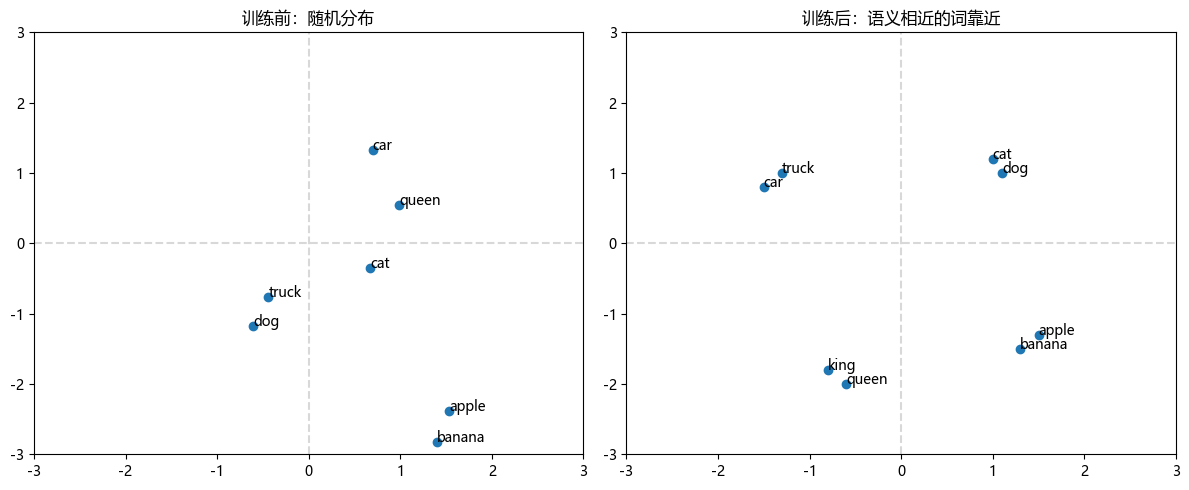

In [10]:
import matplotlib.pyplot as plt


# # 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

# 模拟：训练前后的词向量变化（用2维展示，实际是256维）
torch.manual_seed(123)

# 模拟一组词
words = ['cat', 'dog', 'car', 'truck', 'apple', 'banana', 'king', 'queen']

# 训练前：随机分布
random_vecs = torch.randn(8, 2) * 2  # 8个词，2维随机向量

# 模拟训练后：语义相近的词靠在一起
trained_vecs = torch.tensor([
    [ 1.0,  1.2],  # cat
    [ 1.1,  1.0],  # dog     (和cat很近)
    [-1.5,  0.8],  # car
    [-1.3,  1.0],  # truck   (和car很近)
    [ 1.5, -1.3],  # apple
    [ 1.3, -1.5],  # banana  (和apple很近)
    [-0.8, -1.8],  # king
    [-0.6, -2.0],  # queen   (和king很近)
])

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(random_vecs[:, 0], random_vecs[:, 1])
for i, word in enumerate(words):
    axes[0].annotate(word, (random_vecs[i, 0], random_vecs[i, 1]))
axes[0].set_title('训练前：随机分布')
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

axes[1].scatter(trained_vecs[:, 0], trained_vecs[:, 1])
for i, word in enumerate(words):
    axes[1].annotate(word, (trained_vecs[i, 0], trained_vecs[i, 1]))
axes[1].set_title('训练后：语义相近的词靠近')
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()